Hourly mann-whitney analysis and supporting box plots

In [1]:
# For handling the timeseries
import pandas as pd, os, datetime
import numpy as np

# Statistical analysis
from scipy import stats
from scipy.stats import mannwhitneyu
import math

# For plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px
import matplotlib.lines as mlines
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
pio.renderers.default = 'notebook'

# Import the loader function from your module
os.chdir('/g/data/ng72/ms5578/ID_HW_BARRA')
from process_code import load_generation_data

Dask dashboard: /proxy/8787/status


2025-10-01 08:22:29,573 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle aa05f110919228a32f058b7904e16921 initialized by task ('shuffle-transfer-aa05f110919228a32f058b7904e16921', 2) executed on worker tcp://127.0.0.1:34945
2025-10-01 08:22:37,046 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle aa05f110919228a32f058b7904e16921 deactivated due to stimulus 'task-finished-1759270957.0324614'
2025-10-01 08:22:37,720 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 9794831d046d36d2e88cd1ddfd418422 initialized by task ('shuffle-transfer-9794831d046d36d2e88cd1ddfd418422', 0) executed on worker tcp://127.0.0.1:33725
2025-10-01 08:22:40,409 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 9794831d046d36d2e88cd1ddfd418422 deactivated due to stimulus 'task-finished-1759270959.6240737'


In [2]:
df, info = load_generation_data(
    sdate="2009-07-01",
    edate="2024-06-30",
    mode="hourly",
    ftype=["Wind"],
    apply_remove_negatives=True,
    apply_remove_wind_zeros=True,
    wind_zero_threshold=40,
    apply_min_heatwave_days=True,
    min_heatwave_days_threshold=20,
    apply_clear_agc=False
)

Read gen_details & hw_tseries with Dask: 0.10 sec
Select group: 0.01 sec
--- Starting Dask-Native Process ---


/g/data/ng72/ms5578/ID_HW_BARRA/process_code.py:161: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



Starting final Dask compute...
Dask compute finished.

--- DASK TIMING REPORT ---
duid_setup: 0.00 seconds
csv_bulk_read: 0.23 seconds
filter_and_clean: 0.01 seconds
type_conversion_and_dropna: 0.02 seconds
date_filter: 0.01 seconds
hw_tseries_filter: 5.73 seconds
aggregate_hourly: 0.02 seconds
jitter: 0.22 seconds
final_merge: 0.01 seconds
compute: 75.99 seconds
--- END REPORT ---

Process group: 86.53 sec

--- DEBUG: Calculated Heatwave Days per Generator ---
DUID
MUSSELR1    334
SAPHWF1     206
WRWF1       201
HALLWF2     187
HALLWF1     187
GUNNING1    178
WOODLWN1    171
LKBONNY2    168
GULLRWF1    164
NBHWF1      162
WATERLWF    161
CLEMGPWF    158
SNOWTWN1    157
LKBONNY3    157
BLUFF1      151
TARALGA1    150
MEWF1       143
BOCORWF1    126
BODWF1      122
STWF1       115
SNOWNTH1    109
OAKLAND1    108
COOPGWF1    103
BALDHWF1    101
MACARTH1     98
HDWF1        98
HDWF2        92
HDWF3        92
SNOWSTH1     89
MERCER01     84
GRANWF1      84
CROOKWF2     76
ARWF1        72
K

In [3]:
def hourly_mannwhitu(df, var):
    df = df.copy()
    results = []
    df['hour'] = df['time'].dt.hour
    
    for duid, group in df.groupby('DUID'):
        for hour in range(24):
            group_hour = group[group['hour'] == hour]
            
            group_0 = group_hour[group_hour['EHF_flag'] == 0][var].dropna()
            group_1 = group_hour[group_hour['EHF_flag'] == 1][var].dropna()
            
            # print(f"DUID: {duid}, hour: {hour}, size 0: {len(group_0)}, size 1: {len(group_1)}")
            
            if len(group_0) < 10 or len(group_1) < 10:
                continue
            
            t_stat, p_val = mannwhitneyu(group_0, group_1, alternative='two-sided')
            
            results.append({
                'DUID': duid,
                'hour': hour,
                't_statistic': t_stat,
                'p_value': p_val,
                'median_baseline': group_0.median(),
                'median_hw': group_1.median()
            })
    
    result_df = pd.DataFrame(results)
    return result_df

In [4]:
def plot_hourly_mannwhitu_map(df, info, mannwhitu_results, alpha=0.05,ftypes='Wind and Solar'):
    merged = mannwhitu_results.merge(info, on='DUID', how='left').dropna(subset=['lat_jittered', 'lon_jittered'])
    merged['change'] = merged['median_hw'] - merged['median_baseline']
    merged['size'] = (merged['change'].abs().replace(0, 0.001) * 100) + 20

    def pvalue_significance(p):
        if p < alpha / 10:
            return 'Very strong'
        elif p < alpha:
            return 'Strong'
        elif p < 0.1:
            return 'Weak'
        else:
            return 'Not significant'

    merged['SignificanceLevel'] = merged['p_value'].apply(pvalue_significance)

    def category(row):
        sig = row['SignificanceLevel']
        if sig == 'Not significant':
            return sig
        elif row['change'] < 0:
            return f'{sig} decrease'
        else:
            return f'{sig} increase'

    merged['Category'] = merged.apply(category, axis=1)

    color_map = {
        'Very strong increase': 'darkgreen',
        'Strong increase': 'green',
        'Weak increase': 'lightgreen',
        'Very strong decrease': 'darkred',
        'Strong decrease': 'red',
        'Weak decrease': 'salmon',
        'Not significant': 'lightgray'
    }

    # Ensure 'hour' is string for animation frame to work nicely
    merged['hour'] = merged['hour'].astype(str)

    fig = px.scatter_map(
        merged,
        lat='lat_jittered',
        lon='lon_jittered',
        size='size',
        color='Category',
        color_discrete_map=color_map,
        hover_name='DUID',
        hover_data={
            'hour': True,
            'change': ':.2f',
            'median_baseline': ':.2f',
            'median_hw': ':.2f',
            'p_value': ':.4f',
            'lat_jittered': False,
            'lon_jittered': False,
            'size': False
        },
        zoom=2,
        map_style='carto-darkmatter',
        animation_frame='hour',
        title=f'Hourly Results: Shift in generation distribution for {ftypes}'
    )

    fig.update_layout(
        legend_title_text='Significance and Direction',
        margin=dict(l=10, r=10, t=50, b=10),
        map=dict(center=dict(lat=merged['lat_jittered'].median(), lon=merged['lon_jittered'].median()))
    )

    fig.show()
    return fig


In [5]:
mannwhitu_hourly_results = hourly_mannwhitu(df,'TOTALMWh')
fig = plot_hourly_mannwhitu_map(df, info, mannwhitu_hourly_results,ftypes='Wind')
fig.write_html("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/wind_chapter/hourly_mannwhitu_wind_plotly.html")

In [11]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

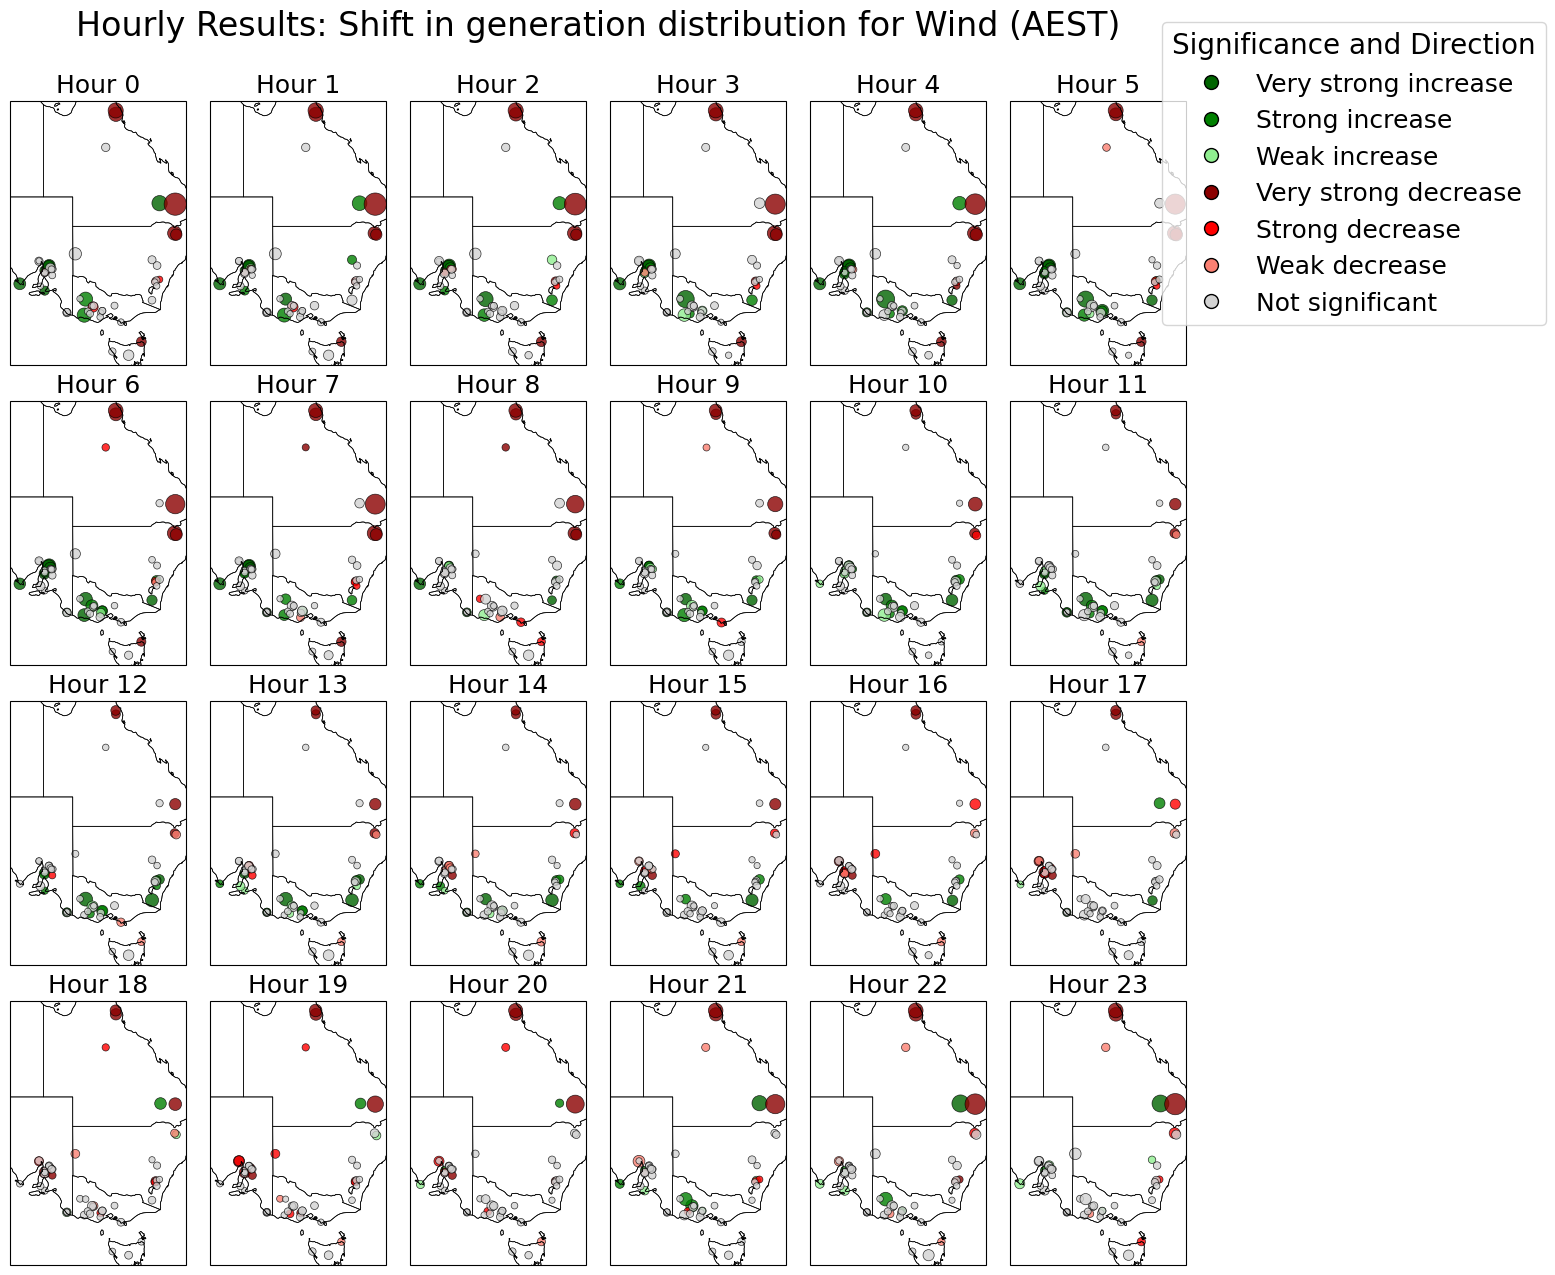

In [12]:
def plot_hourly_mannwhitu_map_matplotlib(df, info, mannwhitu_results, alpha=0.05, ftypes='Wind'):
    merged = mannwhitu_results.merge(info, on='DUID', how='left').dropna(subset=['lat_jittered', 'lon_jittered'])
    merged['change'] = merged['median_hw'] - merged['median_baseline']
    merged['size'] = (merged['change'].abs().replace(0, 1) * 2) + 20

    def pvalue_significance(p):
        if p < alpha / 10:
            return 'Very strong'
        elif p < alpha:
            return 'Strong'
        elif p < 0.1:
            return 'Weak'
        else:
            return 'Not significant'

    merged['SignificanceLevel'] = merged['p_value'].apply(pvalue_significance)

    def category(row):
        sig = row['SignificanceLevel']
        if sig == 'Not significant':
            return sig
        elif row['change'] < 0:
            return f'{sig} decrease'
        else:
            return f'{sig} increase'

    merged['Category'] = merged.apply(category, axis=1)

    color_map = {
        'Very strong increase': 'darkgreen',
        'Strong increase': 'green',
        'Weak increase': 'lightgreen',
        'Very strong decrease': 'darkred',
        'Strong decrease': 'red',
        'Weak decrease': 'salmon',
        'Not significant': 'lightgray'
    }

    # Prepare for faceting by hour
    hours = sorted(merged['hour'].unique())
    n_hours = len(hours)
    ncols = 6
    nrows = int(np.ceil(n_hours / ncols))

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(2*ncols, 3*nrows),
        subplot_kw={'projection': ccrs.PlateCarree()},
        constrained_layout=True  # Use constrained_layout for better spacing
    )

    axes = axes.flatten()

    for idx, hour in enumerate(hours):
        ax = axes[idx]
        data = merged[merged['hour'] == hour]
        for cat, color in color_map.items():
            subset = data[data['Category'] == cat]
            ax.scatter(
                subset['lon_jittered'],
                subset['lat_jittered'],
                s=subset['size'],
                color=color,
                label=cat,
                alpha=0.8,
                edgecolor='k',
                linewidth=0.5,
                transform=ccrs.PlateCarree()
            )
        ax.set_title(f'Hour {hour}', fontsize=18)
        ax.coastlines(lw=0.5)
        ax.add_feature(cfeature.STATES, linestyle='-', lw=0.5)
        ax.set_extent([
            merged['lon_jittered'].min() - 1, merged['lon_jittered'].max() + 1,
            merged['lat_jittered'].min() - 1, merged['lat_jittered'].max() + 1
        ])
        if idx == 0:
            handles, labels = ax.get_legend_handles_labels()

    # Remove empty subplots
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    # Create custom legend handles with fixed marker size
    legend_handles = []
    for cat, color in color_map.items():
        handle = mlines.Line2D(
            [], [], 
            color=color, 
            marker='o', 
            linestyle='None',
            markersize=10,   # Set desired legend marker size here
            markeredgecolor='k',
            label=cat
        )
        legend_handles.append(handle)
    
    # Add a single legend just outside the top right
    fig.legend(
        handles=legend_handles,
        title='Significance and Direction',
        loc='upper right',
        bbox_to_anchor=(1.3, 1.05),
        fontsize=18,           # Make legend labels bigger
        title_fontsize=20      # Make legend title bigger
    )
    fig.suptitle(
        f'Hourly Results: Shift in generation distribution for {ftypes} (AEST)',
        fontsize=24,
        y=1.05
    )

    plt.show()
    return fig

fig = plot_hourly_mannwhitu_map_matplotlib(df, info, mannwhitu_hourly_results)
fig.savefig("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/wind_chapter/hourly_mannwhitu_wind.png", bbox_inches='tight', dpi=300)

In [13]:
def save_violinplots_by_duid_ehf_hourly(df, fuel_type=['Solar','Wind'], output_dir="violinplots", overlay_swarm=True):
    """
    Generate and save violin plots for each DUID split by EHF_flag (0 vs 1), for each hour of day.
    Each hour's plots are saved in a separate subdirectory.
    """ 
    os.makedirs(output_dir, exist_ok=True)

    # Filter data by fuel type
    df_filtered = df[df['fuel_source_primary'].isin(fuel_type)].copy()

    # Ensure 'time' is datetime
    if not np.issubdtype(df_filtered['time'].dtype, np.datetime64):
        df_filtered['time'] = pd.to_datetime(df_filtered['time'])

    # Add hour column
    df_filtered['hour'] = df_filtered['time'].dt.hour

    for hour in sorted(df_filtered['hour'].unique()):
        hour_df = df_filtered[df_filtered['hour'] == hour]
        hour_dir = os.path.join(output_dir, f"hour_{hour:02d}")
        os.makedirs(hour_dir, exist_ok=True)

        for duid in hour_df['DUID'].unique():
            duid_df = hour_df[hour_df['DUID'] == duid].copy()
            if duid_df.empty:
                continue

            fig, ax = plt.subplots(figsize=(6, 6))
            label_map = {0: 'Baseline', 1: 'Heatwave'}
            duid_df['EHF_flag_label'] = duid_df['EHF_flag'].map(label_map)

            sns.violinplot(
                x='EHF_flag_label',
                y='TOTALMWh',
                hue='EHF_flag_label',
                data=duid_df,
                palette={'Baseline': "skyblue", 'Heatwave': "orange"},
                inner='quartile',
                ax=ax,
                legend=False
            )

            if overlay_swarm:
                sns.stripplot(
                    x='EHF_flag_label',
                    y='TOTALMWh',
                    data=duid_df,
                    color='k',
                    alpha=0.5,
                    jitter=0.25,
                    size=2,
                    ax=ax
                )

            ax.set_title(f"Violin Plot for {duid} by Heatwave Status (Hour {hour:02d})")
            ax.set_ylabel("Energy generation during hour (MWh)")

            filepath = os.path.join(hour_dir, f"{duid}_violin_dist_{hour:02d}.png")
            plt.savefig(filepath, dpi=150, bbox_inches="tight")
            plt.close(fig)

    print(f"Saved violin plots by EHF_flag and hour for {len(df_filtered['DUID'].unique())} DUIDs to folder: {output_dir}")

# Example usage:
# save_violinplots_by_duid_ehf_hourly(df, fuel_type=['Wind'], output_dir="/g/data/ng72/ms5578/ID_HW_BARRA/data/output/wind_chapter/violinplot")

In [14]:
def calculate_hourly_summary(df):
    """
    Calculates hourly median, Q1, and Q3 for TOTALMWh, grouped by DUID and EHF_flag.

    Args:
        df (pd.DataFrame): The input DataFrame. Must contain the columns 'time', 
                           'DUID', 'EHF_flag', and 'TOTALMWh'.

    Returns:
        pd.DataFrame: A DataFrame with the hourly summary statistics, ready for plotting.
    """
    # Ensure 'time' is a datetime type
    df['time'] = pd.to_datetime(df['time'])
    
    # Extract the hour from the 'time' column
    df['Hour'] = df['time'].dt.hour
    
    # Define the aggregations to perform
    aggregations = {
        'Median': pd.NamedAgg(column='TOTALMWh', aggfunc='median'),
        'Q1': pd.NamedAgg(column='TOTALMWh', aggfunc=lambda x: x.quantile(0.25)),
        'Q3': pd.NamedAgg(column='TOTALMWh', aggfunc=lambda x: x.quantile(0.75))
    }
    
    # Group by DUID, EHF_flag, and Hour, then calculate the summary statistics
    summary_df = df.groupby(['DUID', 'EHF_flag', 'Hour']).agg(**aggregations).reset_index()
    
    # Add a formatted time label for plotting
    summary_df['TimeLabel'] = summary_df['Hour'].apply(lambda h: f"{h:02d}:00")
    
    # Sort the DataFrame for chronological plotting
    summary_df = summary_df.sort_values(['DUID', 'EHF_flag', 'Hour'])
    
    return summary_df

sample_df = pd.DataFrame(df)

# Calculate the summary DataFrame
summary_for_plotting = calculate_hourly_summary(sample_df)

# Display the first few rows of the resulting DataFrame
print(summary_for_plotting.head())

    DUID  EHF_flag  Hour     Median         Q1         Q3 TimeLabel
0  ARWF1       0.0     0  46.066666  13.354167  98.408333     00:00
1  ARWF1       0.0     1  44.575000  12.225000  97.637500     01:00
2  ARWF1       0.0     2  44.150000  12.043750  94.970833     02:00
3  ARWF1       0.0     3  44.233333  11.852083  95.070833     03:00
4  ARWF1       0.0     4  44.258333  11.816667  96.425000     04:00


In [15]:
cluster_map = pd.read_csv('data/preprocess/wind_spatial_clusters.csv')
summary_for_plotting = summary_for_plotting.merge(cluster_map, on='DUID', how='left')

In [16]:
def plot_duid_facets_and_save(df, target_cluster, save_path=None):

    cluster_df = df[df['cluster'] == target_cluster].copy()
    duids_in_cluster = sorted(cluster_df['DUID'].unique())
    
    if not duids_in_cluster:
        print(f"No data found for cluster: {target_cluster}")
        return

    colors = {0: 'C0', 1: 'C1'}
    flag_map = {0: 'Baseline', 1: 'Heatwave'}

    n_duids = len(duids_in_cluster)
    # ---- CHANGE: Use 4 columns if more than 12 facets, else 2 columns ----
    n_cols = 4 if n_duids > 12 else 2
    n_rows = math.ceil(n_duids / n_cols)

    sfont = 38 if n_duids > 12 else 20
    bfont = 60 if n_duids > 12 else 24
    
    facet_width = 12   # width per subplot in inches
    facet_height = 6  # height per subplot in inches
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(facet_width * n_cols, facet_height * n_rows),
        sharex=True, sharey=False
    )
    
    if n_duids == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, duid in enumerate(duids_in_cluster):
        ax = axes[i]
        duid_df = cluster_df[cluster_df['DUID'] == duid]

        for flag, group in duid_df.groupby('EHF_flag'):
            color = colors[flag]
            ax.scatter(group['TimeLabel'], group['Median'], color=color, s= (100 if n_duids > 12 else 50))
            ax.fill_between(group['TimeLabel'], group['Q1'], group['Q3'], color=color, alpha=0.2)

        ax.set_title(f'DUID: {duid}', fontsize=sfont)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.tick_params(axis='x', labelrotation=45, labelbottom=True, labelsize=20)
        ax.tick_params(axis='y', labelsize=sfont)
        ax.margins(x=0)

    for i in range(n_duids, len(axes)):
        axes[i].set_visible(False)

    fig.supxlabel('Hour of day', fontsize=bfont)
    fig.supylabel('Hourly energy generation (MWh)', fontsize=bfont)
    
    legend_elements = []
    for flag in sorted(colors.keys()):
        label = flag_map.get(flag, f'Flag={flag}')
        color = colors[flag]
        legend_elements.append(Patch(facecolor=color, alpha=0.4, label=f'IQR ({label})'))
        legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=f'Median ({label})'))

    fig.legend(
        handles=legend_elements,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.09),  # Centered below the figure, adjust -0.05 as needed
        ncol=4, 
        fontsize=bfont,
        frameon=False,
        markerscale=2
    )

    plt.tight_layout(rect=[0.03, 0.03, 0.985, 0.985])
    
    # --- CHANGE: Save the figure if a path is provided, otherwise show it ---
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()

# 1. Define the directory where plots will be saved
output_dir = output_dir="/g/data/ng72/ms5578/ID_HW_BARRA/data/output/wind_chapter/median_iqr"
os.makedirs(output_dir, exist_ok=True)

# 2. Get all unique cluster IDs from the DataFrame
unique_clusters = sorted(summary_for_plotting['cluster'].unique())

# 3. Loop through each cluster, create a plot, and save it
for cluster_id in unique_clusters:
    print(f"Generating plot for Cluster {cluster_id}...")
    # Define a unique filename for each cluster's plot
    file_path = os.path.join(output_dir, f'cluster_{cluster_id}_profile.png')
    # Call the function to generate and save the plot
    plot_duid_facets_and_save(summary_for_plotting, cluster_id, save_path=file_path)

print(f"\nAll plots have been saved to the '{output_dir}' directory.")

Generating plot for Cluster 0...
Generating plot for Cluster 1...
Generating plot for Cluster 2...
Generating plot for Cluster 3...
Generating plot for Cluster 4...
Generating plot for Cluster 5...

All plots have been saved to the '/g/data/ng72/ms5578/ID_HW_BARRA/data/output/wind_chapter/median_iqr' directory.


In [17]:
# def plot_duid_boxplot_timeseries(df, target_cluster):
#     """
#     Generates a faceted plot showing an overlapping box plot timeseries for each DUID.
#     This version automatically creates the 'Hour' column from the 'time' column.
#     """
#     plot_df = df.copy()

#     # --- FIX: Ensure 'time' is datetime and create 'Hour' column ---
#     plot_df['time'] = pd.to_datetime(plot_df['time'])
#     plot_df['Hour'] = plot_df['time'].dt.hour
    
#     # Map flags to names for the legend
#     flag_map = {0: 'Baseline', 1: 'Heatwave'}
#     plot_df['Condition'] = plot_df['EHF_flag'].map(flag_map)

#     # Filter data for the target cluster
#     cluster_df = plot_df[plot_df['cluster'] == target_cluster]
#     duids_in_cluster = sorted(cluster_df['DUID'].unique())
    
#     if not duids_in_cluster:
#         print(f"No data found for cluster: {target_cluster}")
#         return

#     # --- Grid Setup ---
#     n_duids = len(duids_in_cluster)
#     n_cols = 2
#     n_rows = math.ceil(n_duids / n_cols)
    
#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 6 * n_rows), sharex=True, sharey=True)
    
#     if n_duids <= 1:
#         axes = [axes]
#     else:
#         axes = axes.flatten()

#     # --- Plotting Loop ---
#     for i, duid in enumerate(duids_in_cluster):
#         ax = axes[i]
#         duid_df = cluster_df[cluster_df['DUID'] == duid]

#         sns.boxplot(
#             data=duid_df,
#             x='Hour', 
#             y='TOTALMWh', 
#             hue='Condition',
#             ax=ax,
#             showfliers=False 
#         )

#         ax.set_title(f'DUID: {duid}', fontsize=18)
#         ax.grid(True, linestyle='--', alpha=0.6)
#         ax.set_ylabel('TOTALMWh', fontsize=14)
#         ax.set_xlabel('') 
#         ax.tick_params(axis='x', labelrotation=45, labelsize=12)
#         ax.tick_params(axis='y', labelsize=12)
        
#         if ax.get_legend():
#             ax.get_legend().remove()

#     # Hide any unused subplots
#     for i in range(n_duids, len(axes)):
#         axes[i].set_visible(False)

#     # --- Figure-level labels and title ---
#     fig.supxlabel('Hour of Day', fontsize=18)
#     fig.suptitle(f'Hourly TOTALMWh Distribution for Cluster {target_cluster}', fontsize=26, y=0.97, x=0.05, ha='left')
    
#     handles, labels = axes[0].get_legend_handles_labels()
#     fig.legend(handles, labels, loc='upper right', fontsize=14, title='Condition')

#     plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])
#     plt.show()


# plot_duid_boxplot_timeseries(df.merge(cluster_map,on='DUID',how='left'), 3)

In [78]:
# This function is also from the previous script and remains unchanged.
def plot_shifts_for_cluster(results_df, target_cluster=None, save_path=None, p_threshold=0.05):
    """
    Plots the hourly shift for a specific cluster from a pre-computed results DataFrame.
    """
    if target_cluster is not None:
        plot_df = results_df[results_df['cluster'] == target_cluster].copy()
    else:
        plot_df = results_df
    
    if plot_df.empty:
        print(f"No data to plot for Cluster {target_cluster}.")
        return

    plot_df['median_shift'] = plot_df['median_hw'] - plot_df['median_baseline']
    plot_df['significant'] = plot_df['p_value'] < p_threshold
    
    fig, ax = plt.subplots(figsize=(18, 10))
    sns.boxplot(data=plot_df, x='hour', y='median_shift', color='lightgray', showfliers=False, ax=ax)
    sns.stripplot(data=plot_df, x='hour', y='median_shift', hue='significant',
                  palette={True: 'red', False: 'black'}, jitter=0.2, ax=ax, size=5)
    
    ax.axhline(0, ls='--', color='black', lw=2)
    if target_cluster is not None:
        ax.set_title(f'Shift in median hourly energy generation (MWh) for Cluster {target_cluster}', fontsize=26, pad=20)
    else:
        ax.set_title(f'Shift in median hourly energy generation (MWh) for all generators', fontsize=26, pad=20)
    ax.set_xlabel('Hour of Day', fontsize=20)
    ax.set_ylabel('Change in Median (MWh)', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=16)
    
    handles, labels = ax.get_legend_handles_labels()
    if len(handles) > 0:
        new_labels = ['Significant' if label == 'True' else 'Not Significant' for label in labels]
        ax.legend(handles, new_labels, title='Significance', title_fontsize=20, fontsize=18, markerscale=2.5, frameon=True)

    plt.tight_layout()
    # If no save_path is given, the plot is shown.
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()

for cluster_id in range(6):
    merged_df = mannwhitu_hourly_results.merge(cluster_map,how='left',on='DUID')
    output_dir = "/g/data/ng72/ms5578/ID_HW_BARRA/data/output/wind_chapter/median_clust_shifts/"
    file_path = os.path.join(output_dir, f"cluster_{cluster_id}_shift_plot.png")
    
    # Call the plotting function with the specified save path
    plot_shifts_for_cluster(
        results_df=merged_df,
        target_cluster=cluster_id,
        save_path=file_path
    )

print("\nAll cluster plots have been saved.")


All cluster plots have been saved.


In [79]:
plot_shifts_for_cluster(
        results_df=merged_df,
        target_cluster=None,
        save_path="/g/data/ng72/ms5578/ID_HW_BARRA/data/output/wind_chapter/median_clust_shifts/all.png")

Figure saved to /g/data/ng72/ms5578/ID_HW_BARRA/data/output/wind_chapter/cluster_scatter.png


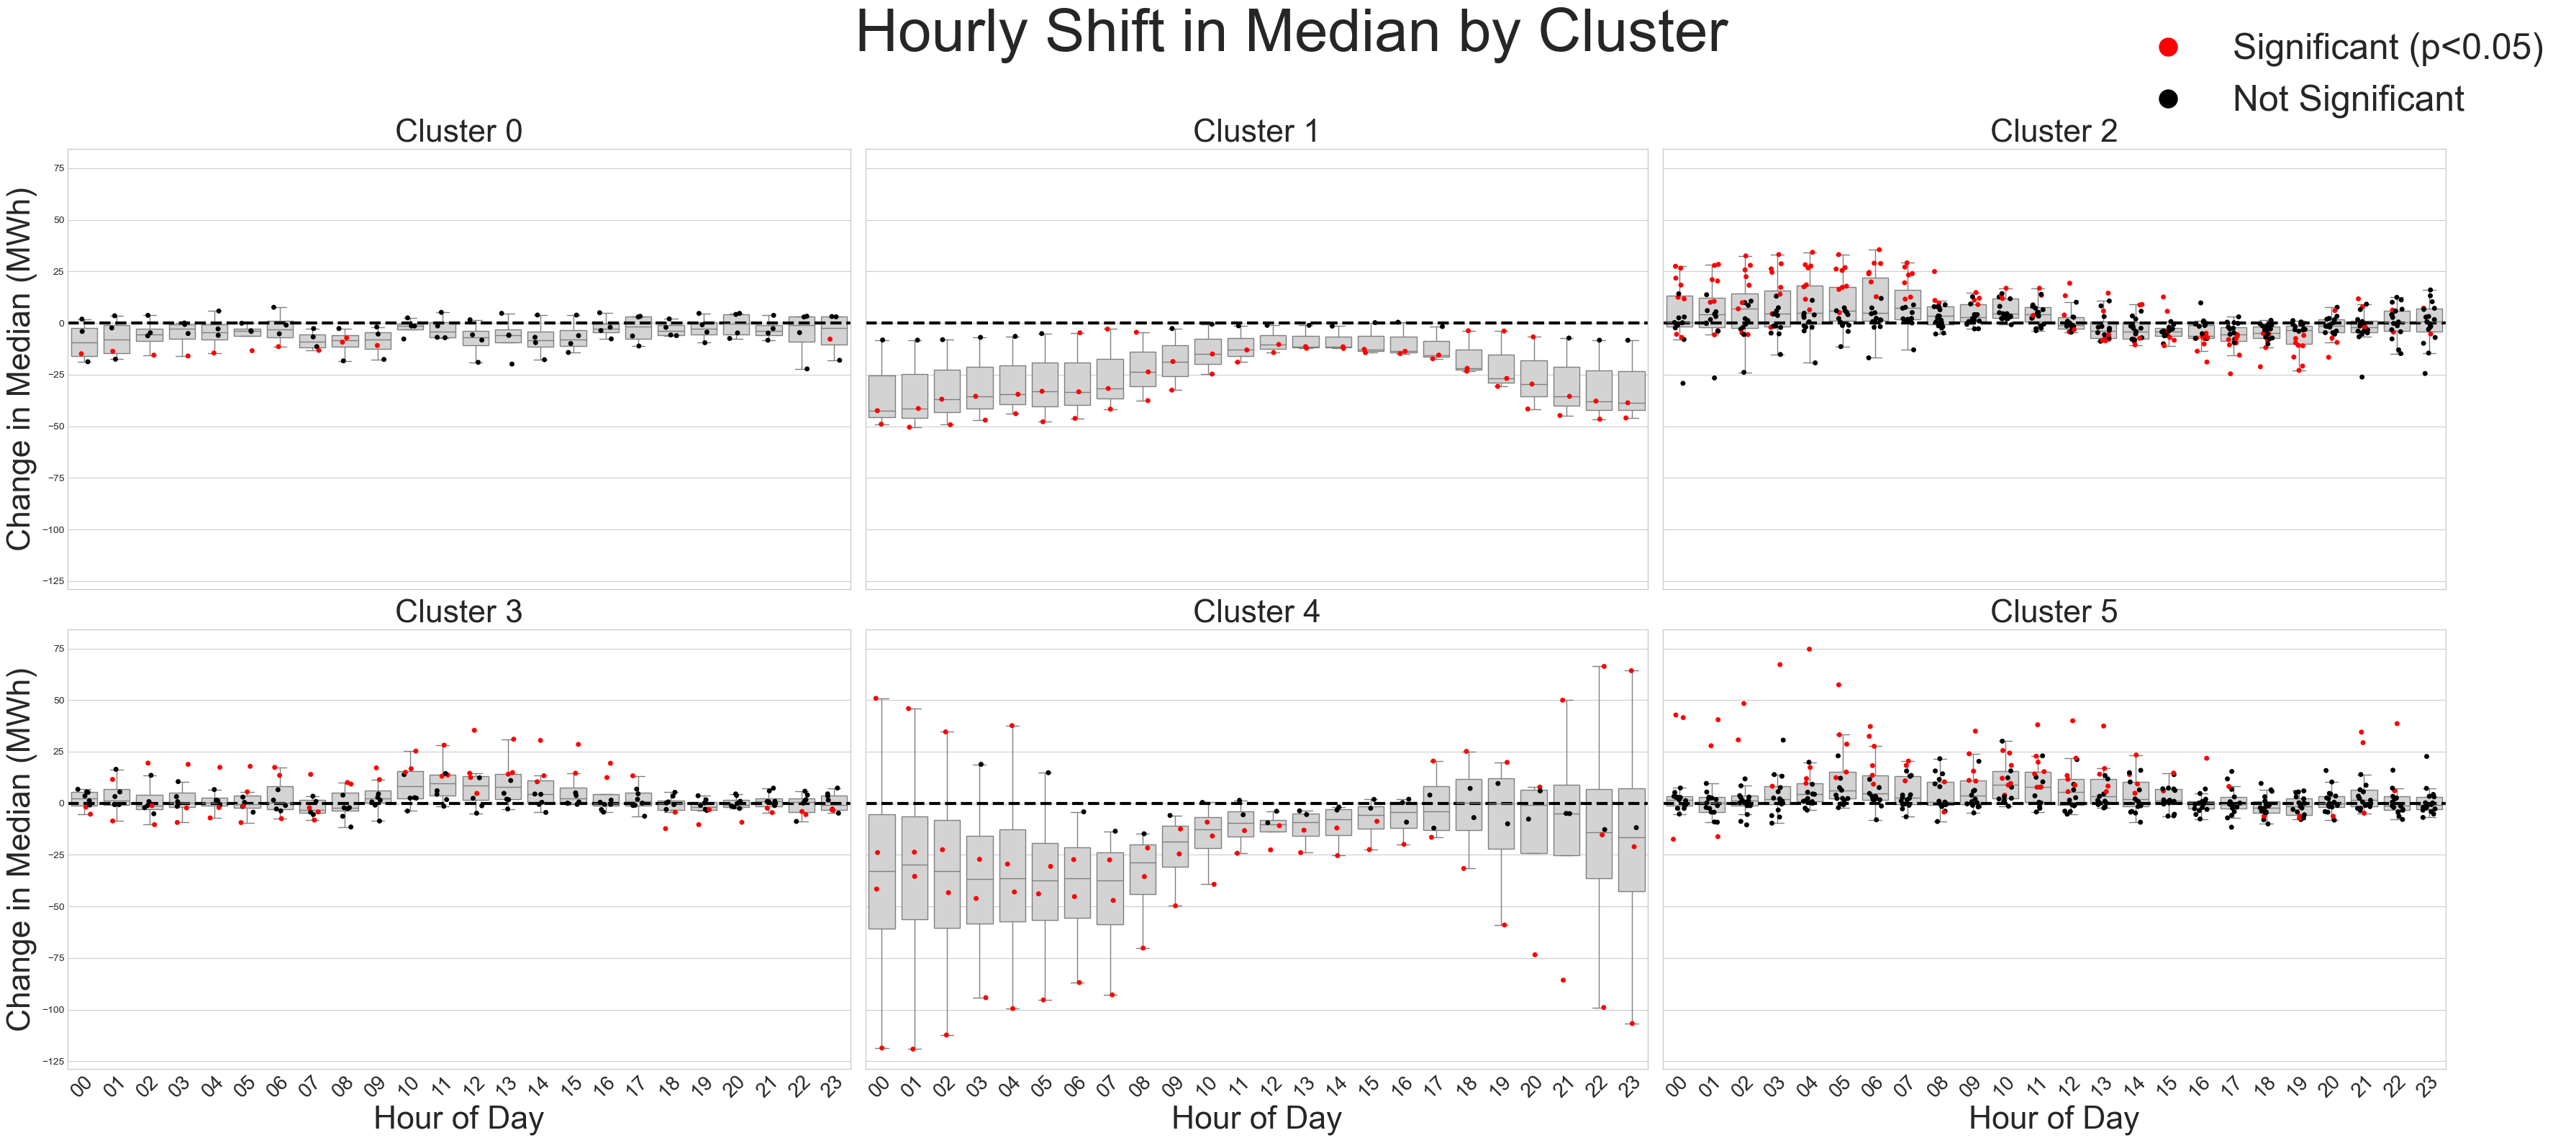

In [55]:
def plot_faceted_cluster_shifts_grid(results_df, p_threshold=0.05, save_path=None):
    """
    Creates a single figure with up to 6 cluster plots in a 2x3 grid layout.
    All facets share the same x and y axes.

    Parameters
    ----------
    results_df : pd.DataFrame
        DataFrame containing columns ['cluster','hour','median_hw','median_baseline','p_value'].
    p_threshold : float, default=0.05
        Threshold for significance test.
    save_path : str or None, default=None
        If provided, saves the figure to this file path.
    """
    plot_df = results_df.copy()
    plot_df['median_shift'] = plot_df['median_hw'] - plot_df['median_baseline']
    plot_df['significant'] = plot_df['p_value'] < p_threshold

    # Ensure hour is categorical with all hour levels for consistent x-axis
    hour_categories = list(range(24))
    plot_df['hour'] = pd.Categorical(plot_df['hour'], categories=hour_categories, ordered=True)

    unique_clusters = sorted(plot_df['cluster'].unique())
    num_clusters = len(unique_clusters)
    n_rows, n_cols = 2, 3

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(36, 16), sharey=True, sharex=True)
    axes = axes.flatten()

    for i in range(n_rows * n_cols):
        ax = axes[i]
        if i < num_clusters:
            cluster_id = unique_clusters[i]
            cluster_data = plot_df[plot_df['cluster'] == cluster_id].dropna(subset=['hour'])

            sns.boxplot(
                data=cluster_data, x='hour', y='median_shift',
                color='lightgray', showfliers=False, ax=ax
            )
            sns.stripplot(
                data=cluster_data, x='hour', y='median_shift',
                hue='significant', palette={True: 'red', False: 'black'},
                jitter=0.2, ax=ax, legend=False
            )

            ax.axhline(0, ls='--', color='black', lw=3)
            ax.set_title(f'Cluster {cluster_id}', fontsize=32)
            
            # Set labels for all subplots, but tick labels will only show on bottom row
            ax.set_ylabel('Change in Median (MWh)', fontsize=32)
            ax.set_xlabel('Hour of Day', fontsize=32)
        else:
            ax.set_visible(False)

    # --- This is the corrected part ---
    # Set xticks and labels for the bottom row of plots
    hour_labels = [f"{h:02d}" for h in range(24)]
    for i in range(n_cols * (n_rows - 1), n_cols * n_rows):
        if i < len(axes) and axes[i].get_visible():
            ax = axes[i]
            ax.set_xticks(range(24))
            ax.set_xticklabels(hour_labels, fontsize=16)
            ax.tick_params(axis='y', labelsize=16)
            # Use plt.setp to rotate labels, which works well with tight_layout
            plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=20)
            
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=f'Significant (p<{p_threshold})',
               markerfacecolor='red', markersize=20),
        Line2D([0], [0], marker='o', color='w', label='Not Significant',
               markerfacecolor='black', markersize=20)
    ]
    fig.legend(handles=legend_elements, loc='upper right', fontsize=36)

    fig.suptitle('Hourly Shift in Median by Cluster', fontsize=60, y=0.99)
    plt.tight_layout(rect=[0, 0, 0.95, 0.96])

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to {save_path}")

    plt.show()

# 4. Call the new faceted plotting function
plot_faceted_cluster_shifts_grid(
    mannwhitu_hourly_results.merge(cluster_map, how='left', on='DUID'),
    save_path="/g/data/ng72/ms5578/ID_HW_BARRA/data/output/wind_chapter/cluster_scatter.png"
)


In [62]:

def plot_cluster_trends(results_df, save_path=None):
    """
    Plots the hourly median shift trend for all clusters on a single line plot.
    The shaded area represents the 95% confidence interval for the median.
    """
    if results_df.empty:
        print("No data to plot.")
        return

    # Prepare the DataFrame for plotting
    plot_df = results_df.copy()
    plot_df['median_shift'] = plot_df['median_hw'] - plot_df['median_baseline']
    
    # Create a single figure and axes for the plot
    fig, ax = plt.subplots(figsize=(20, 12))

    # Create a line plot showing the trend for each cluster.
    # The estimator calculates the median at each hour, and the shaded area is the 95% CI.
    sns.lineplot(data=plot_df, x='hour', y='median_shift', hue='cluster', 
                 ax=ax, palette='viridis', linewidth=2.5, estimator='median', errorbar=('ci', 95))

    ax.axhline(0, ls='--', color='black', lw=2)
    ax.set_title('Trend of Median Hourly Energy Generation Shift by Cluster', fontsize=26, pad=20)
    ax.set_xlabel('Hour of Day', fontsize=20)
    ax.set_ylabel('Change in Median (MWh)', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=16)
    
    # Customize the legend
    handles, labels = ax.get_legend_handles_labels()
    if len(handles) > 0:
        ax.legend(handles, labels, title='Cluster', title_fontsize=20, fontsize=18)

    plt.tight_layout()

    # If a save_path is provided, save the figure; otherwise, display it.
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        plt.close(fig)
        print(f"\nPlot saved to: {save_path}")
    else:
        plt.show()

# --- Main script execution ---

# Merge the dataframes once, outside the plotting function
merged_df = mannwhitu_hourly_results.merge(cluster_map, how='left', on='DUID')

# Define output directory and file path
output_dir = "/g/data/ng72/ms5578/ID_HW_BARRA/data/output/wind_chapter/median_clust_shifts/"
os.makedirs(output_dir, exist_ok=True) # Ensure directory exists
file_path = os.path.join(output_dir, "all_clusters_trend_plot.png")

# Call the new plotting function
plot_cluster_trends(
    results_df=merged_df,
    save_path=file_path
)


Plot saved to: /g/data/ng72/ms5578/ID_HW_BARRA/data/output/wind_chapter/median_clust_shifts/all_clusters_trend_plot.png
